# Assignment 2: Looking into the Future of Comsumer Price Index 

This report presents a time-series analysis of quarterly Consumer Price Index (CPI) data with the goal of producing accurate eight-quarter forecasts. By first conducting a exploratory data analysis, this report looks into the nature of the data and after appropriate tweaks to the data, this report explores two models that were deemed useful out of which one was chosen after careful consideration which was then utilised to calculate the Mean Square Error. 

### Step 1: Loading the data and importing the appropriate packages 

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as smt
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import warnings
import pmdarima as pm
import seaborn as sns
import forecast

train = pd.read_csv('CPI_train.csv')
train['Quarter'] = pd.to_datetime(train['Quarter'], format='%b-%y')
train = train.set_index(train['Quarter'].dt.to_period('Q')).drop(columns='Quarter')

### Step 2: Exploratory Data Analysis 

#### 1) Data cleaning 

Data cleaning is an essential step that aids for a smooth modelling process. The outliers were kept as they often represent real, meaningful events—and throwing them away can do more harm than good. However, we check for missing values and null values as the models that we are considering assume that the data contains a full set of observations.

In [123]:
print("Missing values in train set:")
print(train.isna().sum(), "\n")

Missing values in train set:
CPI    0
dtype: int64 



With no missing values, we can proceed with the data visualisation

#### 2) Data Visualisation 

This process helps us in not only understanding the data further, but also helps us in understanding the general trend of the data which helps us in determining the type of models to utilise and the transformations needed to achieve a low error.

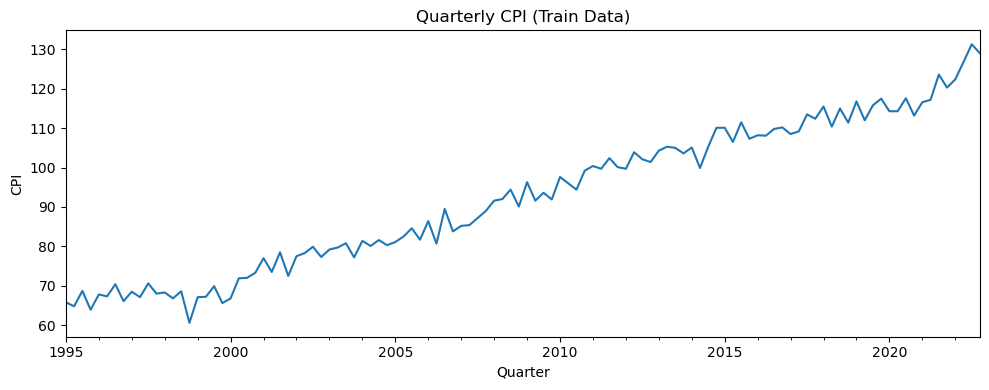

In [127]:
plt.figure(figsize=(10, 4))
train['CPI'].plot(title='Quarterly CPI (Train Data)')
plt.xlabel('Quarter')
plt.ylabel('CPI')
plt.tight_layout()
plt.show()

Through this plot, we observe that the plot is linear, which puts it in the catagory of "Trend". This is because there is a systemic long term increase in the series. This plot does not show any patterns that might indicate that it is seasonal, cyclical or irregular. Moreover, this plot reveals that log-transformation isn't needed as the variation in data does not increase or decrease but rather stay constant. 

#### 3) Checking whether the data is stationary 

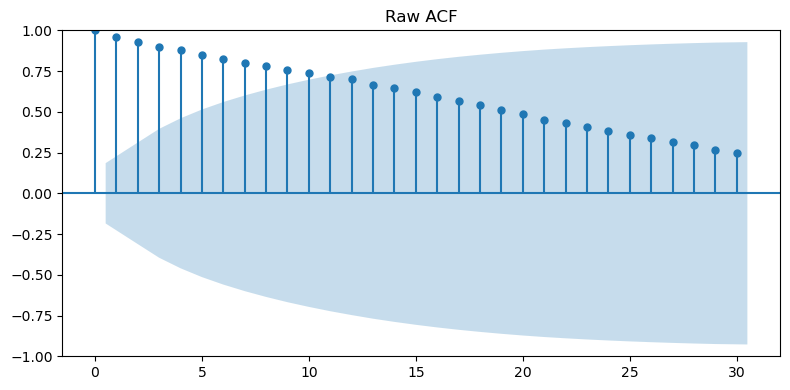

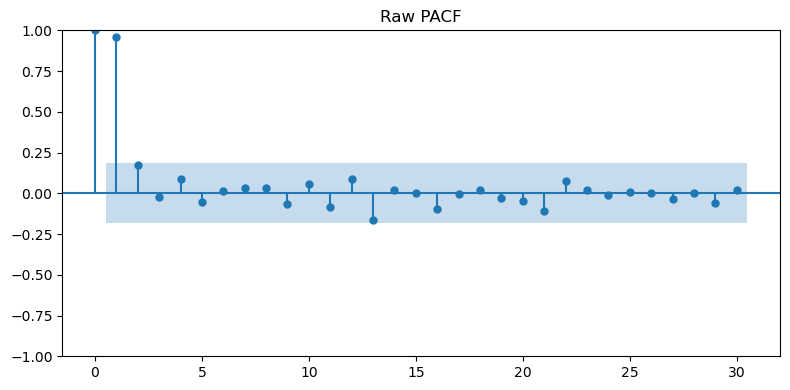

In [130]:
data = train['CPI']
data_diff = data.diff().dropna()


fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(data, lags=30, alpha=0.05, ax=ax)
ax.set_title('Raw ACF')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_pacf(data, lags=30, alpha=0.05, ax=ax)
ax.set_title('Raw PACF')
plt.tight_layout()
plt.show() 

Here, we see that the ACF plot slowly dies down and the PACF plot has two spikes. The ACF plot slowly dying down indicates that the data is not stationary, which is essential for the implication of models. Therefore, we use first-order diffrenciation to make the plot stationary. The PACF plot showing two spikes indicates that the once the effect of lag one is accounted for, there is still new predictive information coming from lag 2. 

#### 4) Differencing 

Now, we need to use first-order diffrencing in order to fit in for either MA, AR or ARMA models as these models assume that the data is stationary. Differencing transforms non-stationary data into stationary data. The ACF plot will also reveal whether there are any seasonal patterns that are present and reveal which value of $d$ is to be used for ARIMA

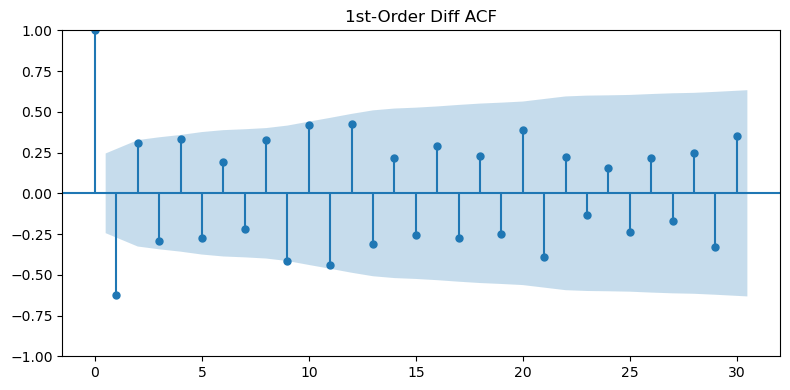

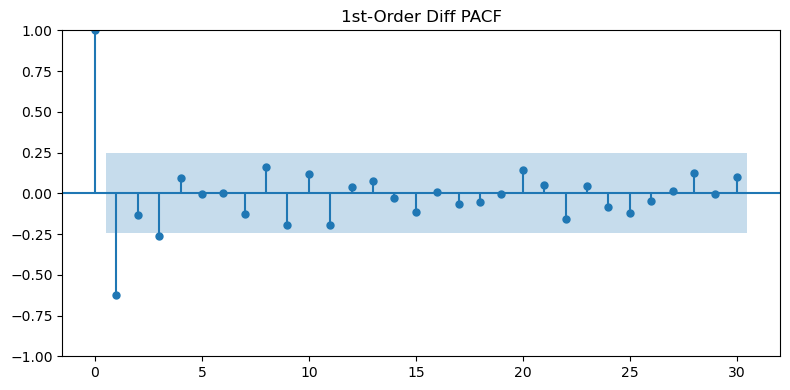

In [134]:
fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(data_diff, lags=30, alpha=0.01, ax=ax)
ax.set_title('1st-Order Diff ACF')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_pacf(data_diff, lags=30, alpha=0.01, ax=ax)
ax.set_title('1st-Order Diff PACF')
plt.tight_layout()
plt.show()

We can observe two spikes in the ACF plot and three in the PACF plot. We can conclude that the data is stationary after first-order differencing as it dies down quickly after the first two lags which is the behaviour we expect when we want to check whethere the data is stationary

### Step 3: Modelling 

There are two models that are being considered for the analysis, they are : ARIMA and Holt. The reason why these models were chosen is as follows:

ARIMA:

In time series forecasting, ARIMA models are generally preferred for non-stationary data because they explicitly integrate a preliminary differencing step (the “I” component) to render the series stationary before estimating autoregressive (AR) and moving-average (MA) terms.  In contrast, fitting AR, MA, or even ARMA models separately on a non-stationary series can lead to biased or inconsistent parameter estimates when trends, unit roots, or other forms of non-stationarity are present.  By embedding differencing within the model structure, ARIMA automates the transformation needed to satisfy the constant-mean, constant-variance assumptions of ARMA, avoids ad hoc pre-processing choices, and allows the Box–Jenkins approach to jointly select the orders $p$, $d$, and $q$ in a unified likelihood-based estimation framework.  This not only simplifies model selection—eliminating the need to manually determine how many differences to apply and then separately identify AR and MA orders—but also typically yields more reliable short-term forecasts and cleaner diagnostics than piecing together separate MA, AR, and ARMA fits. 

Holt:

Holt’s (double) exponential smoothing method is particularly well‐suited to time series that exhibit a clear, approximately linear trend but little or no seasonality.  By maintaining two equations—one for the level and one for the slope—Holt’s method automatically adapts as the trend accelerates or decelerates, without requiring you to manually difference the data or fit a full ARIMA model.  This yields a very simple, computationally light forecasting procedure: you only need to estimate two smoothing parameters (one for level, one for trend), and you can update your forecasts in real time as each new observation arrives.  In practice, Holt’s method often delivers forecasts that are nearly as accurate as more complex trend‐capturing models—especially when data are noisy—while being easier to implement, interpret, and maintain.

Since the data does not demonstrate seasonality -  which can be seen from the first-order differenced ACF plot - Holt-Winters and SARIMA were not considered as an option for implimentation

#### 1) ARIMA 

##### 1.1) Determining the values of $p$ and $q$ and $d$

Based on the ACF and PACF graphs, we determine the values of $p$ to be 2, $d$ to be 1 and $q$ to be 3. But in order to truely understand if these are the best values, grid-search was performed with AIC as its comparison to evaluate the best value.

In [141]:
try:
    import itertools
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    import itertools
    
from statsmodels.tsa.arima.model import ARIMA

d = 1                   
max_p, max_q = 5, 5     
data = data.copy()       


warnings.filterwarnings("ignore")  

results = []
best_aic = np.inf
best_order = None

for p, q in itertools.product(range(max_p+1), range(max_q+1)):
    try:
        model = ARIMA(data, order=(p, d, q)).fit()
        aic   = model.aic
        results.append((p, d, q, aic))
        if aic < best_aic:
            best_aic, best_order = aic, (p, d, q)
    except Exception:
        continue

df = pd.DataFrame(results, columns=['p','d','q','AIC'])
df = df.sort_values('AIC').reset_index(drop=True)

print("Top 5 candidate orders by AIC:")
print(df.head(), "\n")
print("Best order:", best_order, "with AIC =", best_aic)


Top 5 candidate orders by AIC:
   p  d  q         AIC
0  2  1  3  523.954647
1  4  1  2  525.402026
2  2  1  4  525.851534
3  3  1  3  525.879796
4  2  1  5  526.261932 

Best order: (2, 1, 3) with AIC = 523.9546471982226


Since the values match, we can confidently proceed with the modelling process

##### 1.2) Modelling

With these values, 

In [145]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(data, order=(2, 1, 3))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    CPI   No. Observations:                  112
Model:                 ARIMA(2, 1, 3)   Log Likelihood                -255.977
Date:                Wed, 04 Jun 2025   AIC                            523.955
Time:                        17:29:02   BIC                            540.212
Sample:                    03-31-1995   HQIC                           530.550
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0010      0.011     -0.096      0.924      -0.022       0.020
ar.L2          0.9990      0.010     97.656      0.000       0.979       1.019
ma.L1         -0.5254      0.491     -1.069      0.2

##### 1.3) Model diagnostics

To understand the performance of the model, we look into the graph formed by the model's residuals. Ideally, it should resemble white noise 

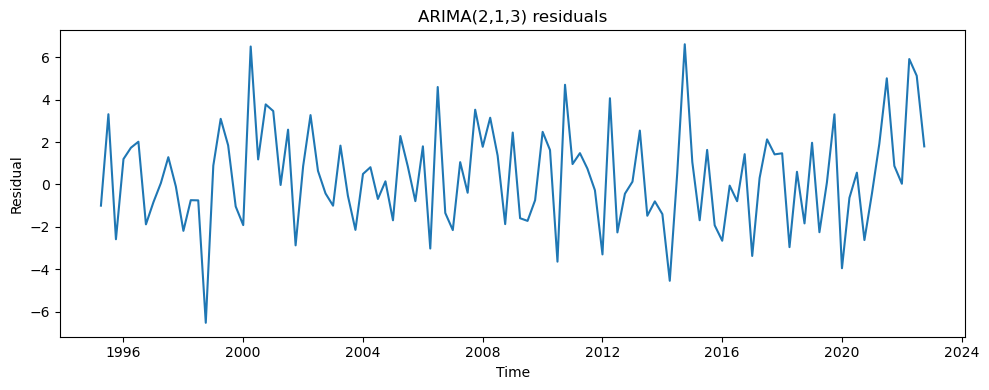

In [148]:
residuals = model_fit.resid.dropna()[1:]           
residuals.index = residuals.index.to_timestamp()    

plt.figure(figsize=(10,4))
plt.plot(residuals.index, residuals.values)
plt.title('ARIMA(2,1,3) residuals')
plt.xlabel('Time')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

We see an AIC value of about 523 and a residual plot that looks close to white noise. We also check whether the residuals behave according to the normal distribution. When the model’s residuals appear (approximately) normally distributed, it means that—after accounting for the structure we have explicitly modeled—all that’s left is random noise with no obvious skew or heavy tails. 

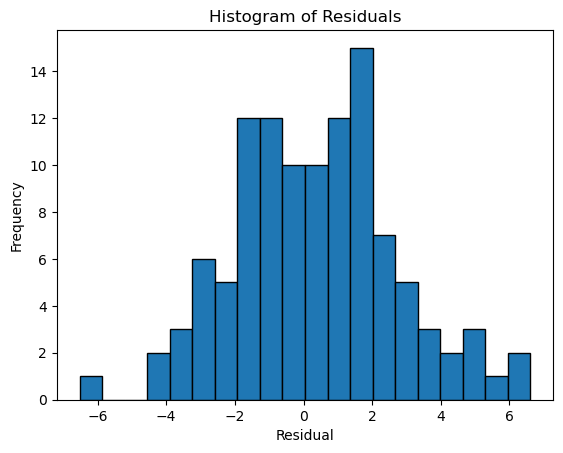

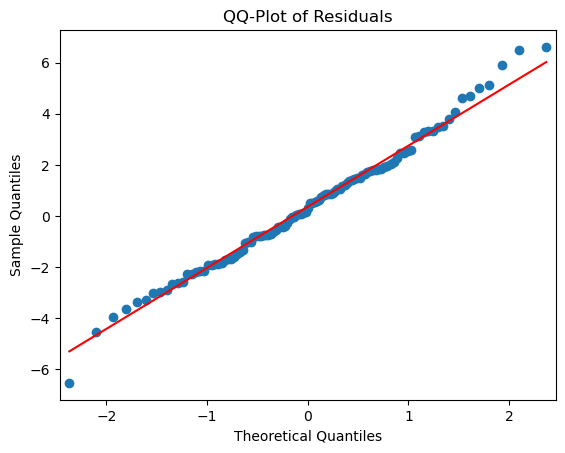

In [150]:
from statsmodels.graphics.gofplots import qqplot
plt.hist(residuals, bins=20, edgecolor='k')
plt.title('Histogram of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

qqplot(residuals, line='s', ax=plt.gca())
plt.title('QQ‐Plot of Residuals')
plt.show()

Since the histogram resembles a bell-shaped curve and the Q-Q plot follows the 45 degree-angled line, which suggests that our method for computing prediction intervals is reliable.  

Now, to understand whether all the autocorrelation is being explained by the model, we look at the ACF graph of the residuals. Ideally, all the spikes should be inside the confidence interval in order to conclude that the residuals are uncorrelated (i.e. white noise), and therefore that the model has adequately captured all of the serial dependence in the data.

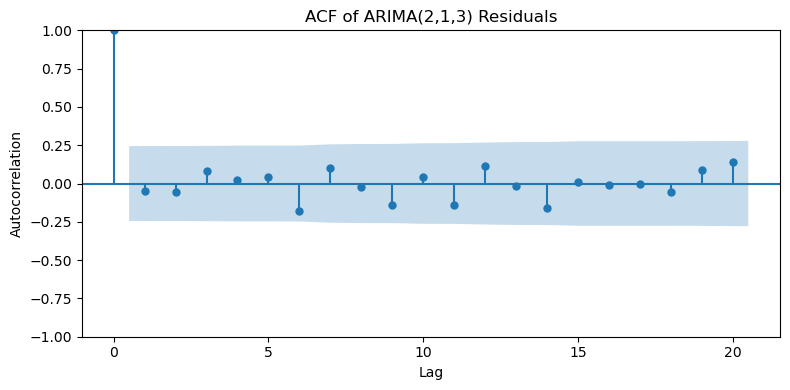

In [153]:
resid = model_fit.resid.dropna()[1:]

fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(resid, lags=20, alpha=0.01, ax=ax)
ax.set_title("ACF of ARIMA(2,1,3) Residuals")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

This isn't our desired outcome, as there is a spike outside the condfidence interval at lag 1. This can happen for a few reasons:

1. **Sampling variability**
   By construction the 95 % bands mean that about 1 in 20 (5 %) lags will exceed them purely by chance—so in a 20-lag plot one can expect one “false alarm” on average.
2. **Finite‐sample bias**
   The bands assume an infinite sample; with only a few dozen observations, the actual distribution of the sample autocorrelations can be a bit wider.
3. **Parameter‐estimation noise**
   This is being computed with estimated AR and MA coefficients. Small estimation errors can leave a tiny bit of leftover autocorrelation at exactly one lag.

Since there is only one spike in the ACF plot, with these reasons, we can still conclude that the there all the autocorrelation is being explained by the model

#### Holt's Method 

This is a more straightforward method, where (like ARIMA) there are no parameters to estimate, rather we let the model automatically optimize the smoothing constants for level (α) and trend (β) by minimizing the in-sample sum of squared errors.

##### 2.1) Modelling

In [158]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.holtwinters import Holt

holt_fit = Holt(data,initialization_method="estimated").fit()
holt_fit.summary()

Dep. Variable:,CPI,No. Observations:,112
Model:,Holt,SSE,780.089
Optimized:,True,AIC,225.382
Trend:,Additive,BIC,236.256
Seasonal:,None,AICC,226.182
Seasonal Periods:,None,Date:,"Wed, 04 Jun 2025"
Box-Cox:,False,Time:,17:29:03
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3438313,alpha,True
smoothing_trend,4.6764e-13,beta,True


##### 2.2) Model Diagnostics 

We once again look at the residuals to see whether it behaves like white noise. We also look into the ACF plot of the residuals to see whether the spikes remian within the confidence interval  

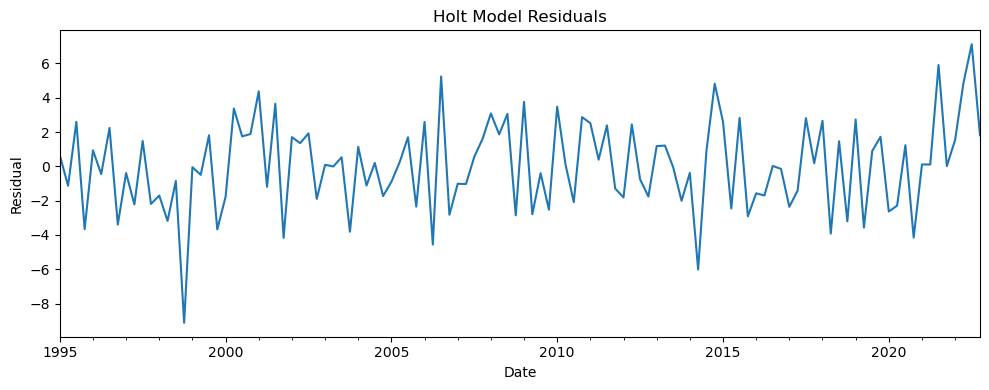

In [161]:
resid_holt = data - holt_fit.fittedvalues

plt.figure(figsize=(10, 4))
resid_holt.plot(
    title="Holt Model Residuals",
    xlabel="Date",
    ylabel="Residual",
    figsize=(10, 4)
)
plt.tight_layout()
plt.show()

The residuals behave like white noise, which is a good indication that the data's variance is explained well by the model 

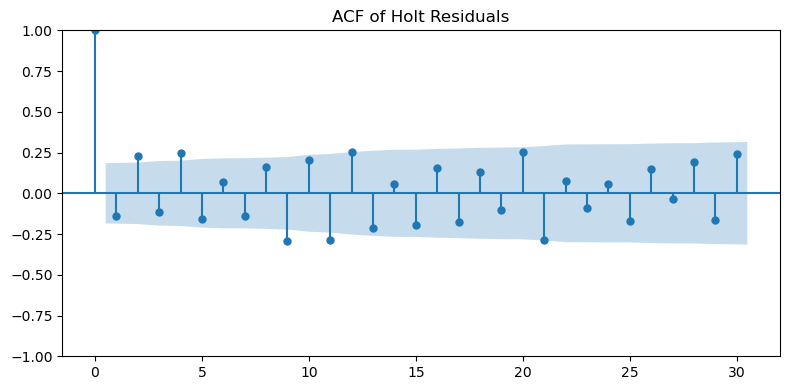

In [163]:
fig, ax = plt.subplots(figsize=(8, 4))
sm.graphics.tsa.plot_acf(resid_holt, lags=30, ax=ax)
ax.set_title("ACF of Holt Residuals")
plt.tight_layout()
plt.show()

We once again, see a spike in lag 1, with a few spikes poking out of the confidence interval. Due to the reasons stated previously, we can conclude that all the autocorrelation is being explained by the model. This means that there is no remaining serial correlation and we can conclude that the residuals behave like white-noise, which is the expected behaviour for a well-rounded model

Now, we look into the histogram and Q-Q plot to identify whether the residuls behave according to the normal distribution

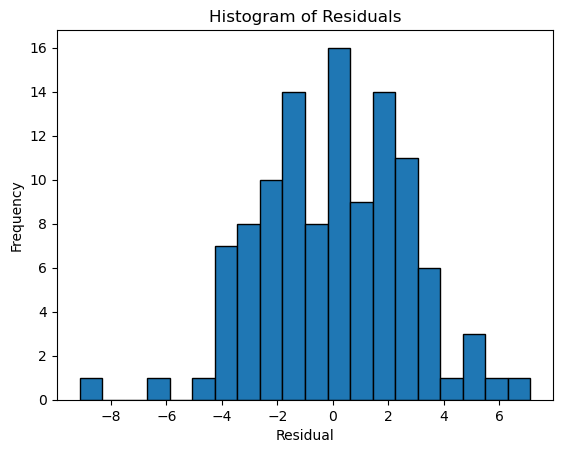

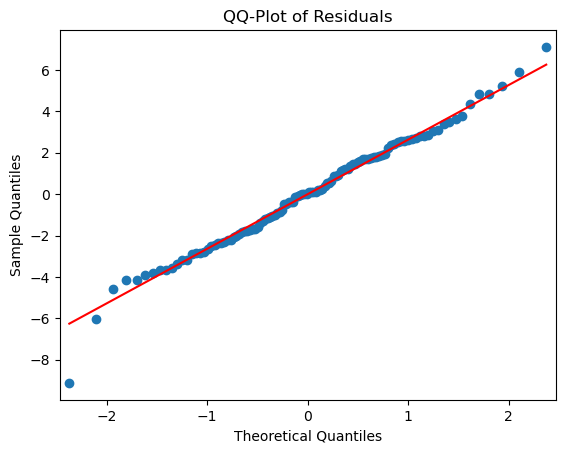

In [166]:
plt.hist(resid_holt, bins=20, edgecolor='k')
plt.title('Histogram of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

qqplot(resid_holt, line='s', ax=plt.gca())
plt.title('QQ‐Plot of Residuals')
plt.show()

These set of plots as well exhibit normality among the residuals which indicates that the model errors are approximately Gaussian white noise and that the model’s assumptions are valid.

#### 3) Model validation

Rolling‐window validation means we keep growing your training data one step at a time, fit the model, and then check how well it predicts the next few points. We do this over and over, always only using past data to forecast the future. This way we can see if the model still works as new data comes in and don’t cheat by looking ahead. It gives a more honest check of how the Holt and ARIMA model will perform on real, unseen data.

In [170]:
h = 8                    
min_train_size = 60     

errors_holt = []
errors_arima = []

for i in range(min_train_size, len(data) - h + 1):
    train = data.iloc[:i]
    test  = data.iloc[i : i + h]
    model_holt  = Holt(train,initialization_method="estimated").fit()
    forecast_holt = model_holt.forecast(h)
    model_arima  = ARIMA(train, order=(2, 1, 3)).fit()
    forecast_arima = model_arima.forecast(h)

    se_holt  = (forecast_holt.values - test.values) ** 2
    se_arima = (forecast_arima - test.values) ** 2

    errors_holt.extend(se_holt)
    errors_arima.extend(se_arima)

mse_holt  = np.mean(errors_holt)
mse_arima = np.mean(errors_arima)

print(f"Holt (linear trend) 8-step rolling-window MSE: {mse_holt:.6f}")
print(f"ARIMA(2,1,3) 8-step rolling-window MSE: {mse_arima:.6f}")

Holt (linear trend) 8-step rolling-window MSE: 7.379789
ARIMA(2,1,3) 8-step rolling-window MSE: 7.594708


While the MSE values of both Holt and ARIMA are close, the MSE value for Holt is the lowest, with a value of 7.37. Now, we can finally move on to the forecasting.

### Step 4: Forecasting

Now, we take the Holt's model and use it to predict the next eight-quarter values

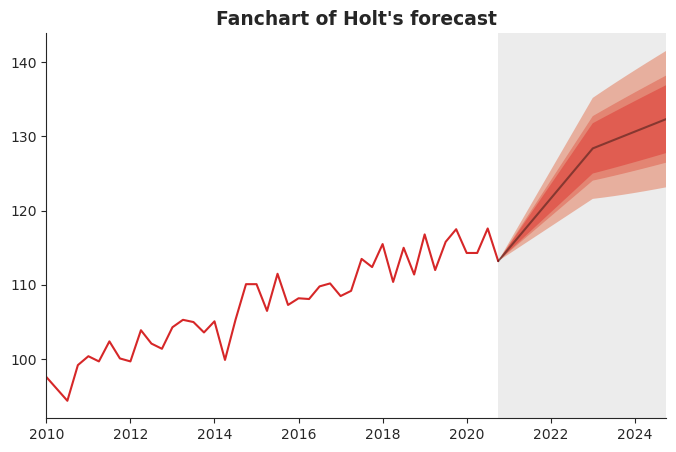

In [174]:
import pandas as pd 
from forecast import intervalforecast, fanchart

h=8

test=pd.period_range(start=data.index[-1]+1, periods=h, freq='Q')
pred=pd.Series(holt_fit.forecast(h), index=test)

intv1=pd.DataFrame(forecast.intervalforecast(holt_fit, h, level=.8), index=test)
intv2=pd.DataFrame(forecast.intervalforecast(holt_fit, h, level=.9), index=test)
intv3=pd.DataFrame(forecast.intervalforecast(holt_fit, h, level=.99), index=test)

fig, ax = forecast.fanchart(train['2010':], pred, intv1, intv2, intv3)
ax.set_xlabel('')
ax.set_xticks([], minor=True)
plt.title("Fanchart of Holt's forecast" , fontsize=13.5, fontweight='bold')

sns.despine()
plt.show()


In [175]:
n_steps = 8
forecast_vals = holt_fit.forecast(steps=n_steps)
last_period = data.index[-1]  
fc_index = pd.period_range(start=last_period + 1, periods=n_steps, freq='Q')
forecast_series = pd.Series(data=forecast_vals, index=fc_index, name='CPI')

forecast_df = pd.DataFrame({
    'Quarter': forecast_series.index.to_timestamp('Q').strftime('%b-%y'),
    'CPI': forecast_series.values
})
forecast_df.to_csv('CPI_forecast.csv', index=False)

### Step 5) Calculating the MSE

This is an essential step in understanding the performance of the model as we evaluate it against a dataset that hasn't been used to train the model. The lower the MSE value is, better the model performed. We are aiming for the lowest score. 

In [ ]:
n_steps = 8
forecast_vals = holt_fit.forecast(steps=n_steps)
last_period = data.index[-1]  
fc_index = pd.period_range(start=last_period + 1, periods=n_steps, freq='Q')
forecast_series = pd.Series(data=forecast_vals, index=fc_index, name='CPI')

from sklearn.metrics import mean_squared_error
CPI_test = pd.read_csv('CPI_test.csv')
CPI_test['Quarter'] = pd.to_datetime(CPI_test['Quarter'], format='%b-%y')
CPI_test = CPI_test.set_index(CPI_test['Quarter'].dt.to_period('Q')).drop(columns='Quarter')

test_data = CPI_test['CPI']
test_error = mean_squared_error(test_data, forecast_vals)
print(test_error)